# Open-Loop Validation

Take held-out val episodes, feed observations through the full T-step denoising chain,
and compare predicted Fff to ground truth. This is Fig. 6 from the TacDiffusion paper.

If predicted actions track ground truth, the model learned the action distribution.
If they look like noise or are flat, something is wrong before we even try closed-loop.

In [1]:
import os
os.chdir(r'c:\Users\ceti\Documents\01_projects\force-insertion-policy')
print(os.getcwd())

c:\Users\ceti\Documents\01_projects\force-insertion-policy


In [2]:
import torch
import numpy as np
import yaml
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import os
from diffusion.ddpm import NoiseEstimator, DDPMSchedule
from shared.insertion_dataset import InsertionDataset

REPO_ROOT = Path(os.getcwd())
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

print(os.getcwd())
print(list(Path('.').glob('configs/*')))

c:\Users\ceti\Documents\01_projects\force-insertion-policy
[WindowsPath('configs/data_config.example.yaml'), WindowsPath('configs/data_config.yaml'), WindowsPath('configs/normalization_stats.yaml')]


In [3]:
CHECKPOINT = Path('checkpoints/df3/best.pt')
CONFIG = Path('configs/data_config.yaml')
HIDDEN_DIM = 512
T = 50

with open(CONFIG, 'r') as f:
    cfg = yaml.safe_load(f)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [4]:
model = NoiseEstimator(hidden_dim=HIDDEN_DIM).to(device)
model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
model.eval()
print(f'Loaded checkpoint from {CHECKPOINT}')

schedule = DDPMSchedule(T=T).to(device)

Loaded checkpoint from checkpoints\df3\best.pt


In [5]:
val_ds = InsertionDataset(cfg, split='val', keep_episodes=True)
print(f'Val episodes: {len(val_ds.observations)}, total timesteps: {len(val_ds)}')

Val episodes: 534, total timesteps: 2204523


In [6]:
@torch.no_grad()
def predict_episode(model, schedule, obs, device):
    """Run full denoising chain for each timestep in an episode."""
    T_steps = len(obs)
    predictions = []

    for t in range(T_steps):
        o_curr = torch.from_numpy(obs[t]).unsqueeze(0).to(device)
        o_prev = torch.from_numpy(obs[t - 1] if t > 0 else obs[t]).unsqueeze(0).to(device)

        a_tau = torch.randn(1, 6, device=device)
        for tau_val in reversed(range(schedule.T)):
            tau = torch.tensor([tau_val], device=device)
            a_tau = schedule.p_sample(model, o_prev, o_curr, a_tau, tau)

        predictions.append(a_tau.squeeze(0).cpu().numpy())

    return np.array(predictions)

## Predict on a val episode
This runs the full 50-step denoising per timestep, so it takes a minute for a long episode.
We subsample to keep it fast.

In [7]:
EP_IDX = 0
obs_full = val_ds.observations[EP_IDX]
act_full = val_ds.actions[EP_IDX]

MAX_STEPS = 1000
step = max(1, len(obs_full) // MAX_STEPS)
sample_idx = np.arange(0, len(obs_full), step)

obs_sub = obs_full[sample_idx]
act_gt = act_full[sample_idx]

print(f'Episode {EP_IDX}: {len(obs_full)} total steps, evaluating {len(sample_idx)} samples (every {step}th step)')

Episode 0: 1713 total steps, evaluating 1713 samples (every 1th step)


In [8]:
print('Running denoising... (this may take a minute)')
act_pred = predict_episode(model, schedule, obs_sub, device)
print(f'Done. Predicted shape: {act_pred.shape}')

Running denoising... (this may take a minute)
Done. Predicted shape: (1713, 6)


## Denormalize back to physical units
Both predictions and ground truth are in normalized space. Convert back for interpretable plots.

In [9]:
act_gt_raw = act_gt * val_ds.act_std + val_ds.act_mean
act_pred_raw = act_pred * val_ds.act_std + val_ds.act_mean

## Full 6D comparison — predicted vs ground truth
Looking for: does the prediction track the general shape of the ground truth?
It won't be perfect (diffusion is stochastic) but it should follow the same patterns.

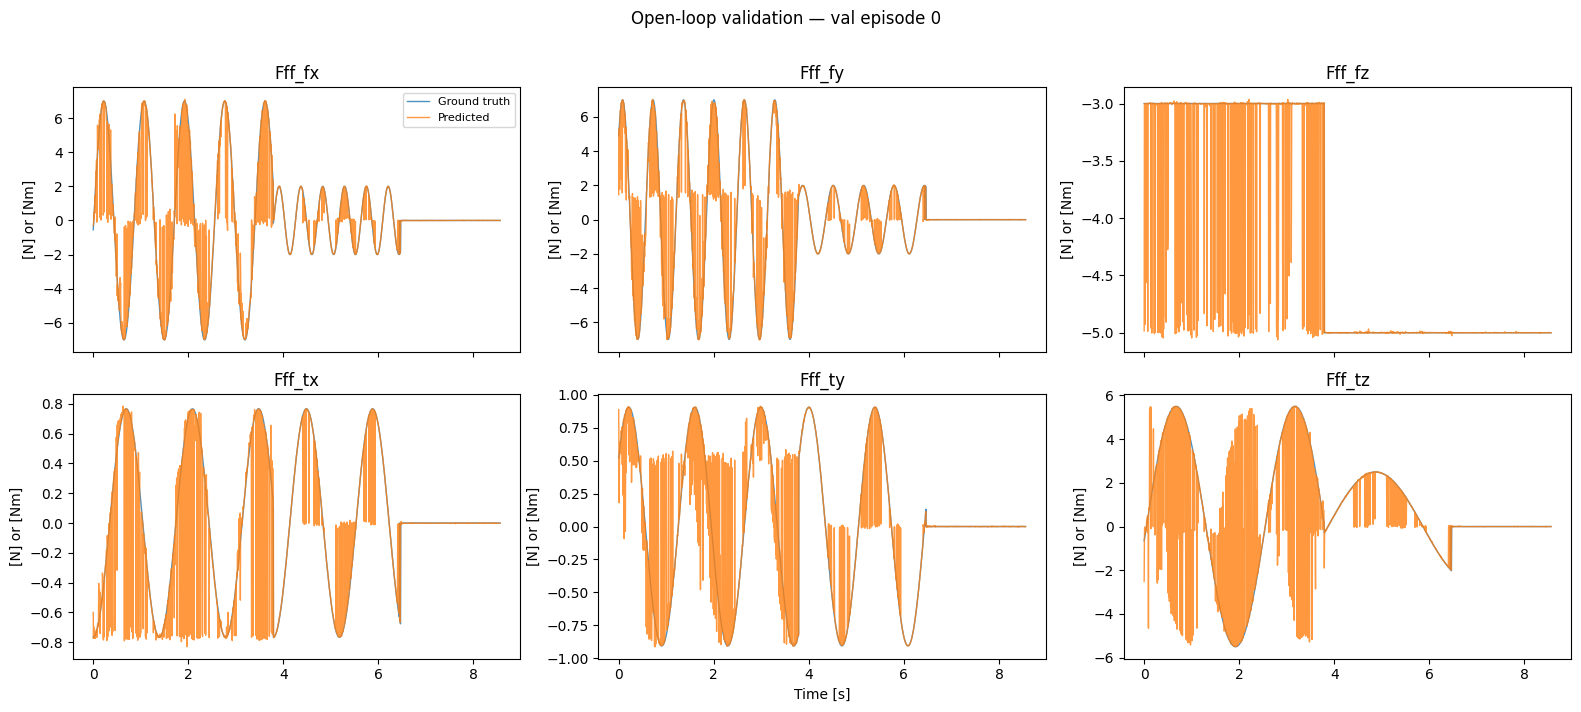

In [10]:
labels = ['Fff_fx', 'Fff_fy', 'Fff_fz', 'Fff_tx', 'Fff_ty', 'Fff_tz']
t_axis = sample_idx * (1.0 / 200)  # convert steps to seconds at 200Hz

fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharex=True)

for i in range(6):
    ax = axes[i // 3, i % 3]
    ax.plot(t_axis, act_gt_raw[:, i], label='Ground truth', alpha=0.8, linewidth=1)
    ax.plot(t_axis, act_pred_raw[:, i], label='Predicted', alpha=0.8, linewidth=1)
    ax.set_title(labels[i])
    ax.set_ylabel('[N] or [Nm]')

axes[0, 0].legend(fontsize=8)
axes[1, 1].set_xlabel('Time [s]')
fig.suptitle(f'Open-loop validation — val episode {EP_IDX}', y=1.01)
plt.tight_layout()

## Denoising process visualization (Fig. 6 style)
Show how a single timestep's action gets reconstructed from pure noise through intermediate denoising steps.

In [11]:
@torch.no_grad()
def denoise_with_intermediates(model, schedule, o_prev, o_curr, device, record_at=None):
    """Run denoising and record intermediate a_tau at specified tau values."""
    if record_at is None:
        record_at = [schedule.T, schedule.T // 2, 1]

    o_prev = torch.from_numpy(o_prev).unsqueeze(0).to(device)
    o_curr = torch.from_numpy(o_curr).unsqueeze(0).to(device)
    a_tau = torch.randn(1, 6, device=device)

    intermediates = {}
    if schedule.T in record_at:
        intermediates[schedule.T] = a_tau.squeeze(0).cpu().numpy().copy()

    for tau_val in reversed(range(schedule.T)):
        tau = torch.tensor([tau_val], device=device)
        a_tau = schedule.p_sample(model, o_prev, o_curr, a_tau, tau)
        if (tau_val + 1) in record_at or tau_val in record_at:
            intermediates[tau_val] = a_tau.squeeze(0).cpu().numpy().copy()

    return intermediates

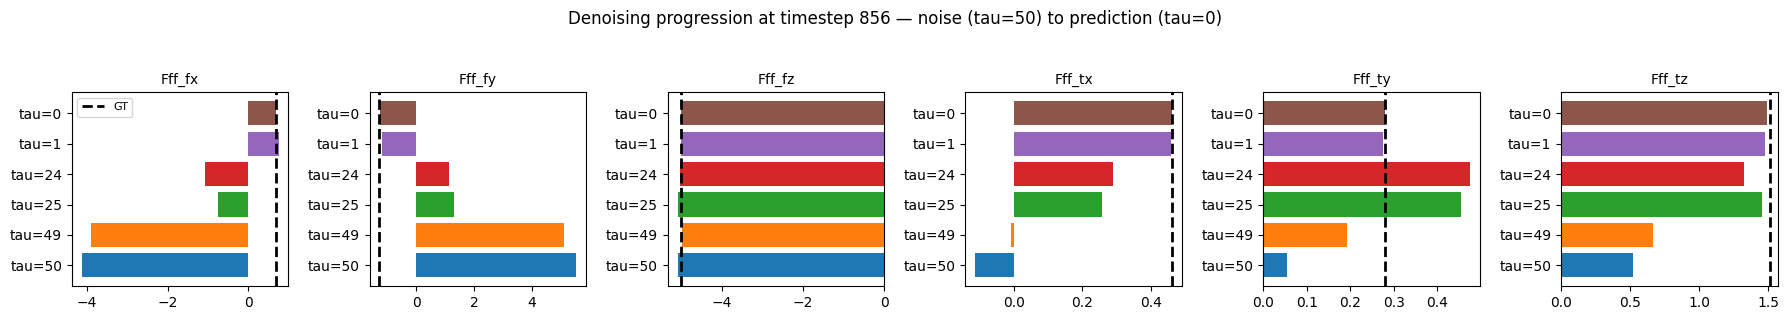

In [12]:
TIMESTEP = len(obs_sub) // 2
o_curr_vis = obs_sub[TIMESTEP]
o_prev_vis = obs_sub[TIMESTEP - 1] if TIMESTEP > 0 else o_curr_vis
gt_vis = act_gt_raw[TIMESTEP]

record_taus = [T, T // 2, 1, 0]
intermediates = denoise_with_intermediates(model, schedule, o_prev_vis, o_curr_vis, device, record_at=record_taus)

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for i in range(6):
    for tau_val, a_int in sorted(intermediates.items(), reverse=True):
        val = a_int[i] * val_ds.act_std[i] + val_ds.act_mean[i]
        axes[i].barh(f'tau={tau_val}', val, color=f'C{list(intermediates.keys()).index(tau_val)}')
    axes[i].axvline(gt_vis[i], color='black', linestyle='--', linewidth=2, label='GT')
    axes[i].set_title(labels[i], fontsize=10)

axes[0].legend(fontsize=8)
fig.suptitle(f'Denoising progression at timestep {TIMESTEP} — noise (tau={T}) to prediction (tau=0)', y=1.05)
plt.tight_layout()

## Per-channel error statistics

In [13]:
errors = act_pred_raw - act_gt_raw
mae = np.abs(errors).mean(axis=0)
rmse = np.sqrt((errors ** 2).mean(axis=0))

print(f'{"Channel":<10} {"MAE":>8} {"RMSE":>8}')
for i, lbl in enumerate(labels):
    print(f'{lbl:<10} {mae[i]:>8.4f} {rmse[i]:>8.4f}')

print(f'\n{"Overall":<10} {mae.mean():>8.4f} {rmse.mean():>8.4f}')

Channel         MAE     RMSE
Fff_fx       0.5022   1.4509
Fff_fy       0.5284   1.5607
Fff_fz       0.1482   0.5319
Fff_tx       0.1038   0.3219
Fff_ty       0.1152   0.3130
Fff_tz       1.0671   2.7635

Overall      0.4108   1.1570


## Try multiple val episodes

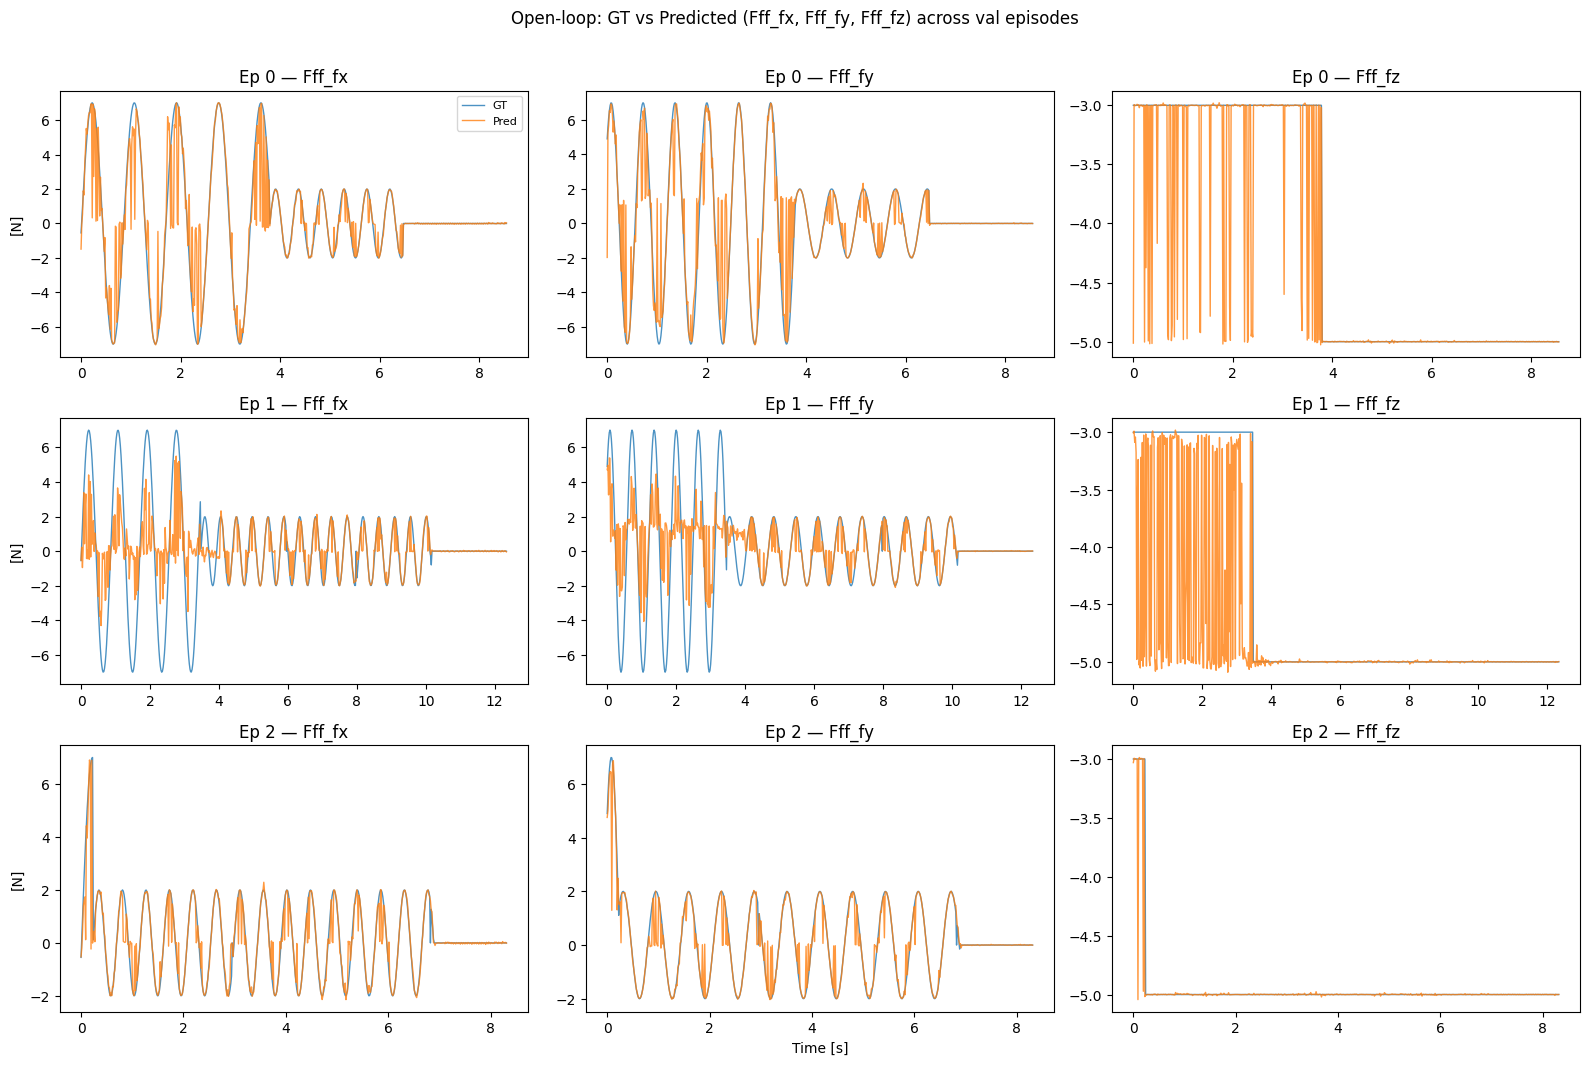

In [14]:
N_EPISODES = min(3, len(val_ds.observations))

fig, axes = plt.subplots(N_EPISODES, 3, figsize=(16, 3.5 * N_EPISODES), sharex=False)
if N_EPISODES == 1:
    axes = axes[np.newaxis, :]

for ep_idx in range(N_EPISODES):
    obs_ep = val_ds.observations[ep_idx]
    act_ep = val_ds.actions[ep_idx]

    step_ep = max(1, len(obs_ep) // 500)
    idx_ep = np.arange(0, len(obs_ep), step_ep)
    obs_s = obs_ep[idx_ep]
    act_s = act_ep[idx_ep]

    pred = predict_episode(model, schedule, obs_s, device)

    act_s_raw = act_s * val_ds.act_std + val_ds.act_mean
    pred_raw = pred * val_ds.act_std + val_ds.act_mean
    t_ax = idx_ep * (1.0 / 200)

    for ch, ch_idx in enumerate([0, 1, 2]):
        axes[ep_idx, ch].plot(t_ax, act_s_raw[:, ch_idx], label='GT', alpha=0.8, linewidth=1)
        axes[ep_idx, ch].plot(t_ax, pred_raw[:, ch_idx], label='Pred', alpha=0.8, linewidth=1)
        axes[ep_idx, ch].set_title(f'Ep {ep_idx} — {labels[ch_idx]}')

    axes[ep_idx, 0].set_ylabel('[N]')

axes[0, 0].legend(fontsize=8)
axes[-1, 1].set_xlabel('Time [s]')
fig.suptitle('Open-loop: GT vs Predicted (Fff_fx, Fff_fy, Fff_fz) across val episodes', y=1.01)
plt.tight_layout()

Denoising full episode (1713 steps) as single series...


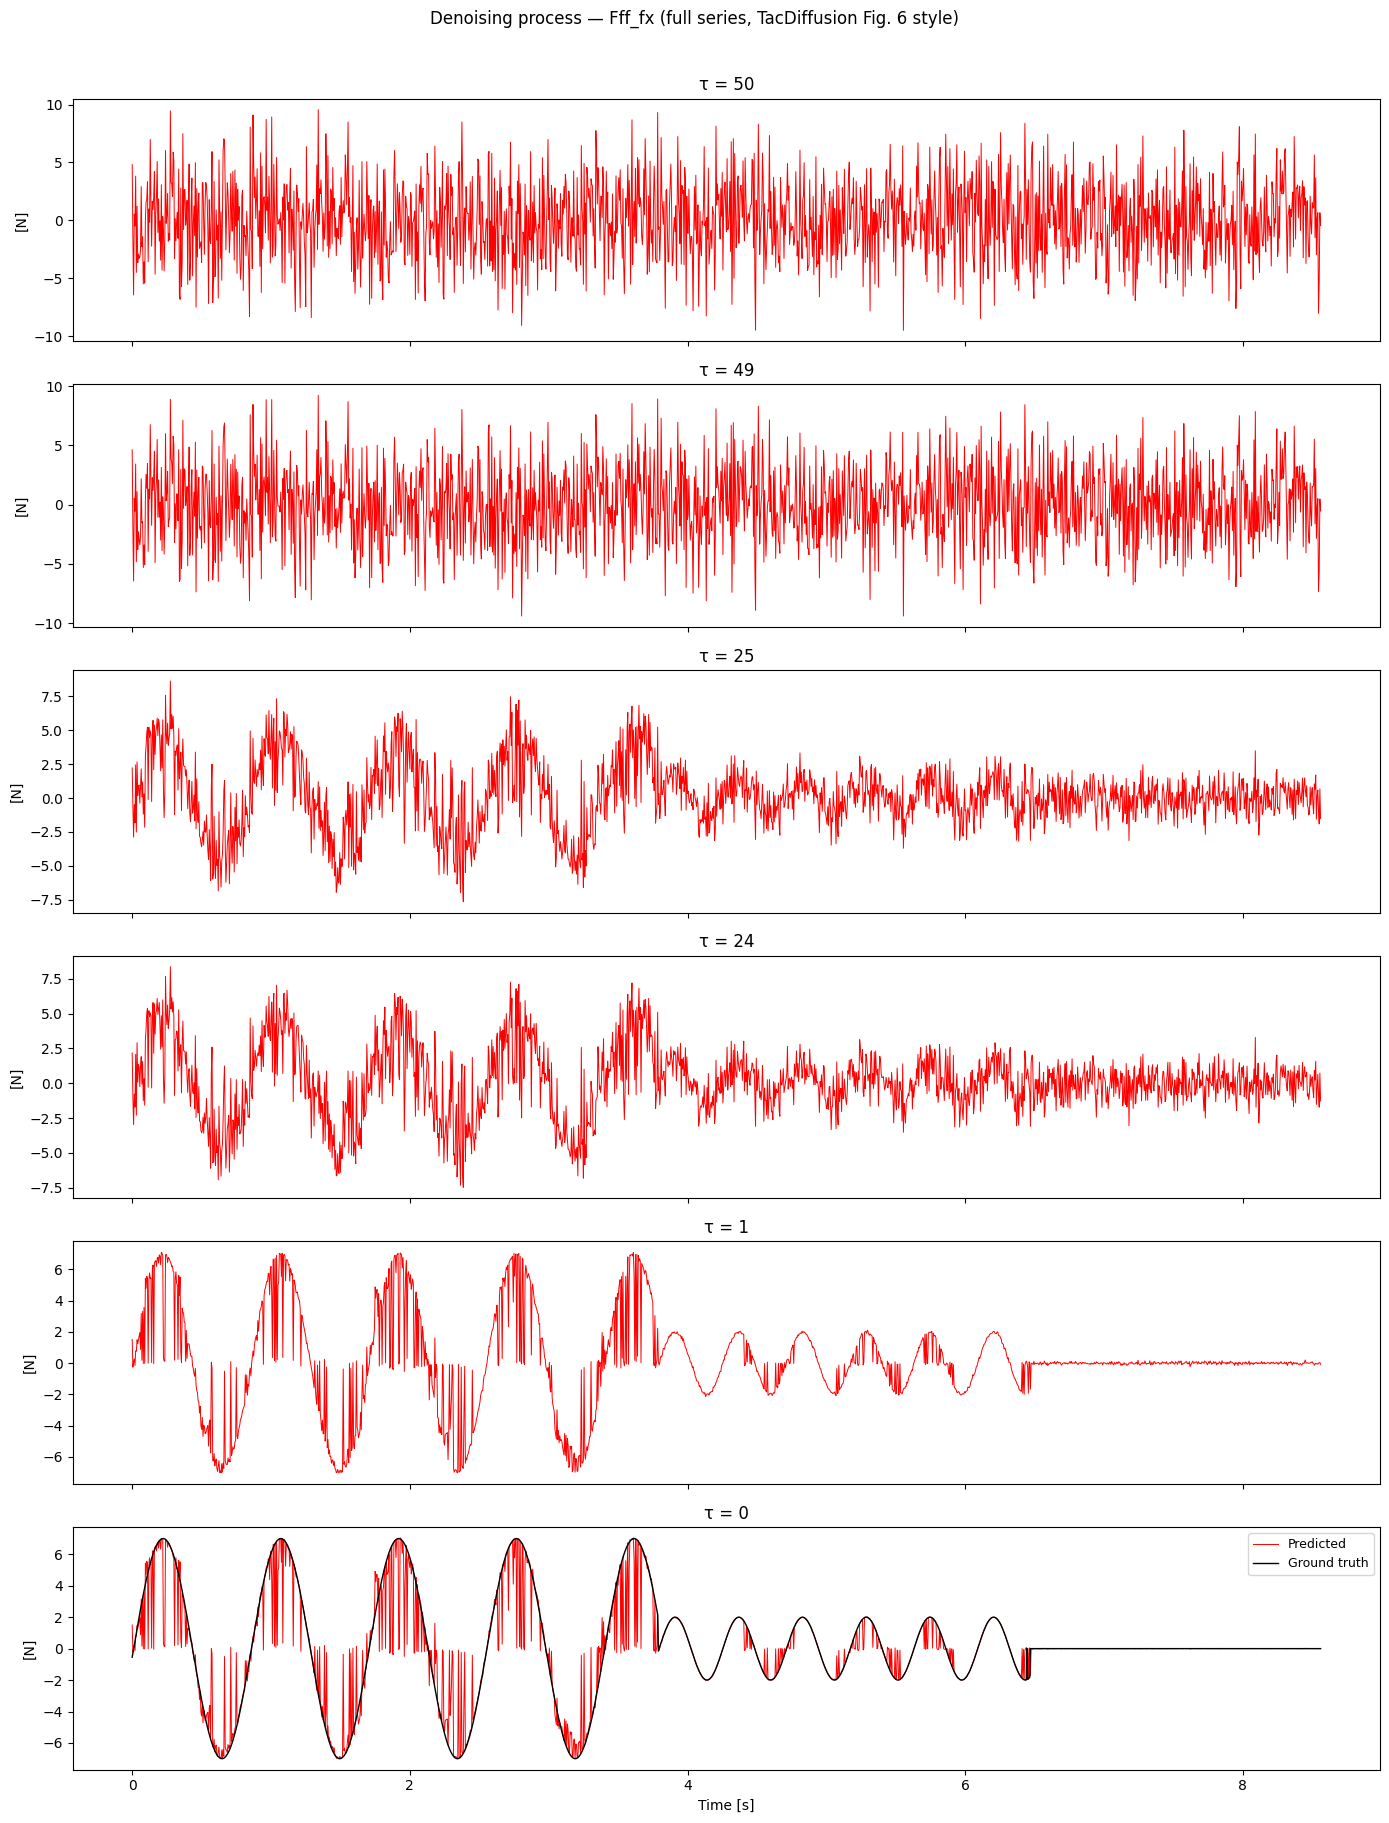

In [15]:
@torch.no_grad()
def predict_episode_series(model, schedule, obs, device):
    """Denoise an entire episode as a single series — reproduces TacDiffusion Fig. 6.
    Returns dict of {tau: (T, 6) array} at recorded tau values."""
    T_steps = len(obs)
    record_at = [schedule.T, schedule.T // 2, 1]

    o_curr_all = torch.from_numpy(obs).to(device)
    o_prev_all = torch.from_numpy(np.vstack([obs[0:1], obs[:-1]])).to(device)

    a_tau = torch.randn(T_steps, 6, device=device)

    intermediates = {schedule.T: (a_tau.cpu().numpy() * val_ds.act_std + val_ds.act_mean).copy()}

    for tau_val in reversed(range(schedule.T)):
        tau = torch.full((T_steps,), tau_val, device=device, dtype=torch.long)
        a_tau = schedule.p_sample(model, o_prev_all, o_curr_all, a_tau, tau)

        if (tau_val + 1) in record_at or tau_val in record_at:
            intermediates[tau_val] = (a_tau.cpu().numpy() * val_ds.act_std + val_ds.act_mean).copy()

    return intermediates


EP_IDX = 0
obs_ep = val_ds.observations[EP_IDX]
act_gt_raw = val_ds.actions[EP_IDX] * val_ds.act_std + val_ds.act_mean
t_axis = np.arange(len(obs_ep)) / 200.0

print(f'Denoising full episode ({len(obs_ep)} steps) as single series...')
intermediates = predict_episode_series(model, schedule, obs_ep, device)

channel = 0  # Fff_fx, change to 1 for fy, 2 for fz, etc.
channel_label = ['Fff_fx', 'Fff_fy', 'Fff_fz', 'Fff_tx', 'Fff_ty', 'Fff_tz'][channel]
taus_to_plot = sorted(intermediates.keys(), reverse=True)

fig, axes = plt.subplots(len(taus_to_plot), 1, figsize=(14, 3 * len(taus_to_plot)), sharex=True)

for i, tau_val in enumerate(taus_to_plot):
    axes[i].plot(t_axis, intermediates[tau_val][:, channel], color='red', linewidth=0.7, label=f'Predicted')
    if tau_val == min(taus_to_plot):
        axes[i].plot(t_axis, act_gt_raw[:, channel], color='black', linewidth=1, label='Ground truth')
        axes[i].legend(fontsize=9)
    axes[i].set_ylabel('[N]')
    axes[i].set_title(f'τ = {tau_val}')

axes[-1].set_xlabel('Time [s]')
fig.suptitle(f'Denoising process — {channel_label} (full series, TacDiffusion Fig. 6 style)', y=1.01)
plt.tight_layout()